# 03 — El producto end-to-end: del scraping a la dirección del dólar

Esta notebook recorre **todo el sistema, en orden y sin saltarse nada**:

| § | Etapa | Qué verás |
|---|---|---|
| 1 | **Scraping de noticias** (Bronze→Silver) | Los titulares crudos del día, sin LLM |
| 2 | **El movimiento de las monedas** | TRM oficial + Brent, DXY y bolsa colombiana |
| 3 | **GOLD: los topics y la golden query** | Cada noticia clasificada (topic, canal FX, severidad, entidades) y la consulta que filtra el oro del ruido |
| 4 | **El grafo de noticias** | Tópicos ↔ entidades con comunidades — los clusters del día |
| 5 | **El sistema multiagéntico** | QUÉ patrón es (la respuesta explícita) + el grafo LangGraph **renderizado** |
| 6 | **La corrida y la predicción** | El grafo completo ejecutándose → `DirectionalCall` |
| 7 | **Medición** | La tabla `predictions` que califica al sistema contra la realidad |

**El objetivo de estudio** (invariante desde el día 1): clasificar la **dirección** del
USD/COP — `down`/`up`/`neutral` — cruzando noticias analizadas por agentes con la señal
de la serie de tiempo, bajo una capa de racionalidad que obliga al contra-argumento y
acota la confianza por contrato.

In [1]:
# Setup — limpio: sin os.chdir, sin adivinar rutas con cwd.
# cop_fx.paths resuelve la raíz desde el paquete y Settings lee el .env absoluto.
import sys

try:
    import cop_fx  # noqa: F401
except ModuleNotFoundError:
    raise RuntimeError(
        f"KERNEL EQUIVOCADO ({sys.executable}).\n"
        "En VS Code: selector de kernel → 'Python (cop-fx-intelligence)'."
    ) from None

from cop_fx.config.settings import get_settings
from cop_fx.paths import DATA_DIR, PROJECT_ROOT

settings = get_settings()
assert settings.openai_api_key is not None, f"Falta OPENAI_API_KEY en {PROJECT_ROOT / '.env'}"

print(f"✓ Proyecto : {PROJECT_ROOT.name}")
print(f"✓ LLM      : {settings.llm_model} ({settings.llm_provider})")
print(f"✓ Datos    : {DATA_DIR}")

✓ Proyecto : cop-fx-intelligence
✓ LLM      : gpt-5.4-mini (openai)
✓ Datos    : /Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/data


## 1. Scraping de noticias — Bronze → Silver

Determinista y aburrido a propósito: feeds RSS de economía colombiana, CNN Colombia
(HTML de respaldo) y los feeds macro del lado USD (CNBC, MarketWatch). Cero LLM,
cero costo. El resultado es `list[Article]` — el Silver que alimenta a los agentes.

In [2]:
import pandas as pd

from cop_fx.data.news_fetcher import NewsFetcher

articles = NewsFetcher().fetch()
df_silver = pd.DataFrame(
    {
        "fecha": [a.published_at.strftime("%Y-%m-%d") for a in articles],
        "fuente": [a.source[:24] for a in articles],
        "titular": [a.title for a in articles],
    }
)
print(f"✓ {len(articles)} artículos SILVER — ⚠ esta tabla muestra SOLO titulares")
print("  (así llega el crudo; el TEXTO COMPLETO se descarga y analiza en la sección 3)")
print("  Orden: por FECHA con fuentes intercaladas — mismo día = mismo pie.\n")
df_silver.head(15)

16:49:06  INFO      cop_fx.data.cnn_fetcher  —  CNNColombiaFetcher: starting (max=100)


16:49:07  WARNING   cop_fx.data.cnn_fetcher  —  RSS feed returned 0 entries: https://cnnespanol.cnn.com/colombia/feed/


16:49:07  WARNING   cop_fx.data.cnn_fetcher  —  Colombia RSS empty — trying main CNN Español feed


16:49:07  WARNING   cop_fx.data.cnn_fetcher  —  RSS feed returned 0 entries: https://cnnespanol.cnn.com/feed/


16:49:08  SUCCESS   cop_fx.data.cnn_fetcher  —  HTML: fetched 3437430 bytes from https://cnnespanol.cnn.com/colombia/


...

16:49:08  SUCCESS   cop_fx.data.cnn_fetcher  —  HTML: extracted 44 articles


16:49:08  SUCCESS   cop_fx.data.cnn_fetcher  —  CNNColombiaFetcher: 44 unique articles ready | with author: 0/44


16:49:08  SUCCESS   cop_fx.data.news_fetcher  —  Fetched 100 unique articles total


✓ 100 artículos SILVER — ⚠ esta tabla muestra SOLO titulares
  (así llega el crudo; el TEXTO COMPLETO se descarga y analiza en la sección 3)
  Orden: por FECHA con fuentes intercaladas — mismo día = mismo pie.



,fecha,fuente,titular
0,2026-06-12,La República - Economía,Ministerio de Hacienda ajustó al alza meta de ...
1,2026-06-12,PORTAFOLIO.CO -Economía,Gobierno anuncia descuentos en la factura de e...
2,2026-06-12,Economy,UK economy shrank 0.1% in April as Iran confli...
3,2026-06-12,La República - Economía,"A abril, seis de cada 10 informales son trabaj..."
4,2026-06-12,PORTAFOLIO.CO -Economía,Estos son los destinos favoritos de los colomb...
5,2026-06-12,Economy,A Chinese start-up's unfolding dilemma exposes...
6,2026-06-12,La República - Economía,Superservicios pone la lupa sobre 598 empresas...
7,2026-06-12,PORTAFOLIO.CO -Economía,Gobierno anuncia una nueva reforma tributaria ...
8,2026-06-12,La República - Economía,Una persona estuvo en situación de pobreza mon...
9,2026-06-12,PORTAFOLIO.CO -Economía,Gobierno anuncia más de $16 billones para infr...


## 2. El movimiento de las monedas

La TRM oficial (datos.gov.co) más el contexto de mercado que el estudio de la
notebook 02 validó: Brent, DXY y la bolsa colombiana (GXG) — recuerda que el equity
de ayer es el único predictor adelantado que pasó el filtro lead-lag.

16:49:09  INFO      cop_fx.data.fx_fetcher  —  FX source: TRM datos.gov.co


16:49:09  INFO      cop_fx.data.fx_fetcher  —  Fetched 236 FX rows (start=2025-06-12, end=2026-06-12)


16:49:10  INFO      cop_fx.data.market_fetcher  —  Serie brent (BZ=F): 301 filas


16:49:10  INFO      cop_fx.data.market_fetcher  —  Serie dxy (DX-Y.NYB): 301 filas


16:49:10  INFO      cop_fx.data.market_fetcher  —  Serie equity (GXG): 363 filas


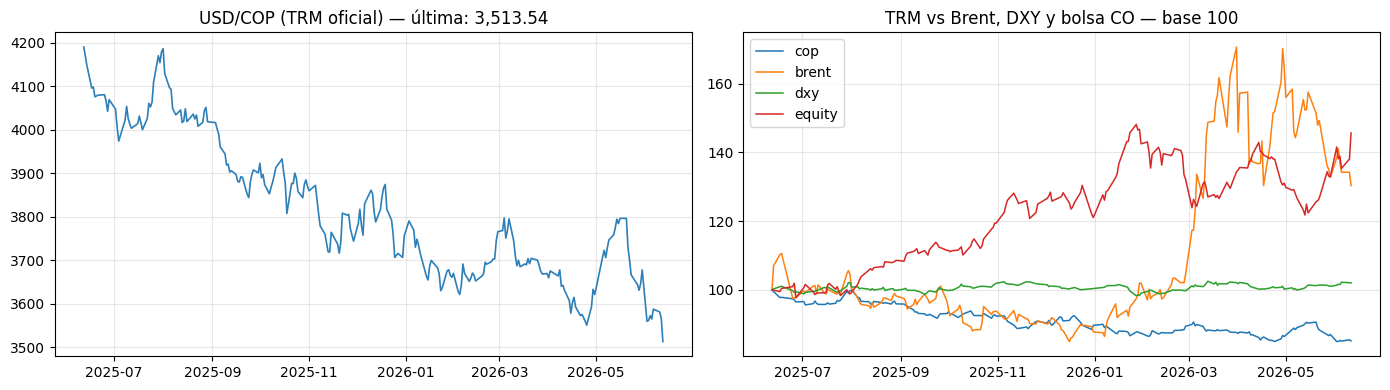

In [3]:
import matplotlib.pyplot as plt

from cop_fx.data.fx_fetcher import FXFetcher
from cop_fx.data.market_fetcher import fetch_market_panel

fx = FXFetcher().fetch()
panel = fetch_market_panel(fx)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(fx["ds"], fx["y"], color="#2c7fb8", lw=1.2)
axes[0].set_title(f"USD/COP (TRM oficial) — última: {fx['y'].iloc[-1]:,.2f}")
axes[0].grid(alpha=0.3)
for col in [c for c in panel.columns if c != "ds"]:
    axes[1].plot(panel["ds"], 100 * panel[col] / panel[col].iloc[0], label=col, lw=1.1)
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title("TRM vs Brent, DXY y bolsa CO — base 100")
plt.tight_layout(); plt.show()

## 3. GOLD — los topics y la *golden query*

Aquí el LLM toca el dato por primera vez. El `NewsAnalyzer` (el mismo del pipeline)
clasifica cada artículo con la **taxonomía de dos niveles**:

- `topic`: qué ES la noticia (15 dominios: `political_risk`, `monetary_policy`,
  `public_health`, `environment_climate`, `sports`...)
- `fx_relevance` + `fx_channel`: si transmite al dólar y POR QUÉ mecanismo —
  con coherencia forzada por contrato (deportes ⇒ relevancia `none` ⇒ pesa 0).

In [4]:
from cop_fx.analysis.news_analyzer import NewsAnalyzer
from cop_fx.config.settings import get_settings
from cop_fx.data.article_body import attach_bodies

# Selección GOLD — en el ORDEN del fetcher (fecha + fuentes intercaladas):
# se descarga el texto completo y se FILTRA lo que no tiene texto analizable.
# NO se reordena por longitud: extraíble ≠ relevante (la reforma tributaria
# de Portafolio vale aunque su paywall solo deje una línea de resumen).
cfg = get_settings()
pool = articles[:40]
attach_bodies(pool, max_articles=40)

def _text_len(a):
    return len(getattr(a, "body", "") or a.summary)

subset = [a for a in pool if _text_len(a) >= cfg.min_analyzable_chars][:20]
print(f"Pool {len(pool)} → descartados {len(pool) - sum(1 for a in pool if _text_len(a) >= cfg.min_analyzable_chars)} sin texto → analizamos {len(subset)}")

analysis = NewsAnalyzer().analyze(subset)

pd.set_option("display.max_colwidth", 90)
df_gold = pd.DataFrame([
    {
        "titular": it.article.title[:55],
        "autor": getattr(it.article, "author", "") or "(sin autor)",
        "fuente": it.article.source[:14],
        "noticia": ((getattr(it.article, "body", "") or it.article.summary)[:85] + "…"),
        "chars_texto": _text_len(it.article),
        "topic": it.topic,
        "fx_relevance": it.fx_relevance,
        "fx_channel": it.fx_channel,
        "severity": it.severity,
        "bullish_cop": it.bullish_cop,
    }
    for it in analysis.items
])
print(f"✓ {len(df_gold)} GOLD · fuentes: {sorted(df_gold['fuente'].unique())} · "
      f"texto medio {df_gold['chars_texto'].mean():,.0f} chars\n")
print(f"Narrativa del día:\n{analysis.narrative}\n")
df_gold

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


16:49:12  WARNING   cop_fx.data.article_body  —  Cuerpo demasiado corto (241 chars) en https://www.portafolio.co/economia/gobierno-anuncia-descuentos-en-la-factura-de-energia-para-quienes-ahorren-y-cobros-mas-altos-a-quienes-gasten-mas-496093 — probable paywall/boilerplate


16:49:14  WARNING   cop_fx.data.article_body  —  Cuerpo demasiado corto (241 chars) en https://www.portafolio.co/economia/regiones/estos-son-los-destinos-favoritos-de-los-colombianos-para-las-vacaciones-de-mitad-de-ano-segun-anato-496092 — probable paywall/boilerplate


16:49:15  WARNING   cop_fx.data.article_body  —  Cuerpo demasiado corto (241 chars) en https://www.portafolio.co/economia/gobierno-anuncia-una-nueva-reforma-tributaria-para-el-2027-con-la-que-recaudaria-30-billones-496090 — probable paywall/boilerplate


16:49:16  WARNING   cop_fx.data.article_body  —  Cuerpo demasiado corto (241 chars) en https://www.portafolio.co/economia/regiones/gobierno-anuncia-mas-de-16-billones-para-infraestructura-en-narino-y-avances-en-pasto-catambuco-clave-496089 — probable paywall/boilerplate


...

16:49:27  WARNING   cop_fx.data.article_body  —  Cuerpo demasiado corto (277 chars) en https://cnnespanol.cnn.com/2026/06/11/colombia/video/world-cup-mundial-colombia-guadalajara-mexico — probable paywall/boilerplate


16:49:28  INFO      cop_fx.data.article_body  —  Cuerpos descargados: 29/40 artículos


Pool 40 → descartados 2 sin texto → analizamos 20


✓ 20 GOLD · fuentes: ['Economy', 'La República -', 'PORTAFOLIO.CO '] · texto medio 1,549 chars

Narrativa del día:
El sesgo del día es mixto, pero dominan los riesgos fiscales e inflacionarios en Colombia. Los anuncios de mayor déficit, inflación más alta y nueva reforma tributaria presionan el USD/COP al alza por canal de country risk. En contraste, más inversión en infraestructura, mejores puertos y avances logísticos aportan soporte marginal al COP vía growth y terms of trade, aunque con menor intensidad.



,titular,autor,fuente,noticia,chars_texto,topic,fx_relevance,fx_channel,severity,bullish_cop
0,Ministerio de Hacienda ajustó al alza meta de déficit f,(sin autor),La República -,"El Ministerio de Hacienda , liderado por Germán Ávila , hizo la presentación oficial …",3500,fiscal_policy,direct,country_risk,high,False
1,Gobierno anuncia descuentos en la factura de energía pa,(sin autor),PORTAFOLIO.CO,"El ministro de Minas y Energía, Edwin Palma, confirmó medidas para enfrentar la sequí…",98,energy_commodities,indirect,inflation,medium,True
2,UK economy shrank 0.1% in April as Iran conflict weighe,(sin autor),Economy,One of the biggest contributors to the decline in services came from a fall of 9.1% i…,1786,us_global_macro,indirect,growth,low,False
3,"A abril, seis de cada 10 informales son trabajadores po",(sin autor),La República -,El Dane reveló los más recientes resultados de mercado laboral correspondientes al tr…,2912,labor_social,indirect,growth,low,False
4,Estos son los destinos favoritos de los colombianos par,(sin autor),PORTAFOLIO.CO,"Cartagena concentra 22,8% de las reservas nacionales, seguida por San Andrés, Santa M…",105,other,none,none,low,False
5,A Chinese start-up's unfolding dilemma exposes cracks i,(sin autor),Economy,The structure reflects how China funds its industrial strategy.\nLocal authorities hav…,2079,financial_markets,indirect,capital_flows,low,False
6,Superservicios pone la lupa sobre 598 empresas para eva,(sin autor),La República -,"Con el objetivo de verificar el cumplimiento de las obligaciones regulatorias, la Sup…",1533,energy_commodities,none,none,low,False
7,Gobierno anuncia una nueva reforma tributaria para el 2,(sin autor),PORTAFOLIO.CO,"Según la cartera, el país requiere un ajuste fiscal de entre 1,4 y 1,6 puntos del Pro…",105,fiscal_policy,direct,country_risk,high,False
8,Una persona estuvo en situación de pobreza monetaria si,(sin autor),La República -,El Dane reveló el último informe de pobreza monetaria y pobreza monetaria extrema cor…,3054,other,indirect,growth,low,False
9,Gobierno anuncia más de $16 billones para infraestructu,(sin autor),PORTAFOLIO.CO,Los diseños definitivos de Fase III registran avance de 50% y se evalúan recursos por…,104,fiscal_policy,indirect,growth,low,True


In [5]:
# EVIDENCIA — esto es literalmente lo que lee el agente (no el titular):
for a in subset[:3]:
    text = (getattr(a, "body", "") or a.summary)[:350]
    print(f"━━ [{a.source[:20]}] {a.title[:70]}")
    print(f"   TEXTO ({_text_len(a)} chars): «{text}…»\n")

━━ [La República - Econo] Ministerio de Hacienda ajustó al alza meta de déficit fiscal y de infl
   TEXTO (3500 chars): «El Ministerio de Hacienda , liderado por Germán Ávila , hizo la presentación oficial del Marco Fiscal de Mediano Plazo, Mfmp, de 2026. De acuerdo con los datos presentados por el jefe de la cartera, se ajustó al alza la meta de inflación y del déficit fiscal para el cierre de este año. Puntualmente, la meta de déficit fiscal pasó de 5,1% del PIB en…»

━━ [PORTAFOLIO.CO -Econo] Gobierno anuncia descuentos en la factura de energía para quienes ahor
   TEXTO (98 chars): «El ministro de Minas y Energía, Edwin Palma, confirmó medidas para enfrentar la sequía y el calor.…»

━━ [Economy] UK economy shrank 0.1% in April as Iran conflict weighed on growth
   TEXTO (1786 chars): «One of the biggest contributors to the decline in services came from a fall of 9.1% in sports, amusement and recreation activities. The Office for National Statistics (ONS) said that this was the larg

In [6]:
# LA GOLDEN QUERY: separar el oro del ruido.
# De todo lo scrapeado, ¿qué tiene canal de transmisión al dólar y con qué fuerza?
golden = (
    df_gold[df_gold["fx_relevance"] != "none"]
    .sort_values("severity", key=lambda s: s.map({"high": 0, "medium": 1, "low": 2}))
    .reset_index(drop=True)
)
print(f"Golden query: {len(golden)} de {len(df_gold)} artículos tienen señal FX\n")
display(golden)

print("\nTopic × relevancia FX — cuánto del día es señal vs ruido:")
pd.crosstab(df_gold["topic"], df_gold["fx_relevance"])

Golden query: 15 de 20 artículos tienen señal FX



,titular,autor,fuente,noticia,chars_texto,topic,fx_relevance,fx_channel,severity,bullish_cop
0,Ministerio de Hacienda ajustó al alza meta de déficit f,(sin autor),La República -,"El Ministerio de Hacienda , liderado por Germán Ávila , hizo la presentación oficial …",3500,fiscal_policy,direct,country_risk,high,False
1,Gobierno anuncia una nueva reforma tributaria para el 2,(sin autor),PORTAFOLIO.CO,"Según la cartera, el país requiere un ajuste fiscal de entre 1,4 y 1,6 puntos del Pro…",105,fiscal_policy,direct,country_risk,high,False
2,Marco Fiscal de Media Plazo: Gobierno mantiene proyecci,(sin autor),PORTAFOLIO.CO,"El MinHacienda, Germán Ávila prevé un Producto Interno Bruto del 2,6% y una inflación…",109,fiscal_policy,direct,country_risk,high,False
3,Gobierno anuncia descuentos en la factura de energía pa,(sin autor),PORTAFOLIO.CO,"El ministro de Minas y Energía, Edwin Palma, confirmó medidas para enfrentar la sequí…",98,energy_commodities,indirect,inflation,medium,True
4,El Niño “muy fuerte” se extendería hasta febrero tras l,(sin autor),La República -,"Luego de varios meses de alerta y seguimiento permanente a las predicciones, el I nst…",3500,agro_commodities,indirect,inflation,medium,False
5,UK economy shrank 0.1% in April as Iran conflict weighe,(sin autor),Economy,One of the biggest contributors to the decline in services came from a fall of 9.1% i…,1786,us_global_macro,indirect,growth,low,False
6,"A abril, seis de cada 10 informales son trabajadores po",(sin autor),La República -,El Dane reveló los más recientes resultados de mercado laboral correspondientes al tr…,2912,labor_social,indirect,growth,low,False
7,A Chinese start-up's unfolding dilemma exposes cracks i,(sin autor),Economy,The structure reflects how China funds its industrial strategy.\nLocal authorities hav…,2079,financial_markets,indirect,capital_flows,low,False
8,Una persona estuvo en situación de pobreza monetaria si,(sin autor),La República -,El Dane reveló el último informe de pobreza monetaria y pobreza monetaria extrema cor…,3054,other,indirect,growth,low,False
9,Gobierno anuncia más de $16 billones para infraestructu,(sin autor),PORTAFOLIO.CO,Los diseños definitivos de Fase III registran avance de 50% y se evalúan recursos por…,104,fiscal_policy,indirect,growth,low,True



Topic × relevancia FX — cuánto del día es señal vs ruido:


fx_relevance,direct,indirect,none
topic,,,
agro_commodities,0,1,0
energy_commodities,0,2,1
financial_markets,0,1,0
fiscal_policy,3,3,1
labor_social,0,1,0
other,0,1,1
political_risk,0,0,2
trade,0,2,0
us_global_macro,0,1,0


## 4. El grafo de noticias — tópicos ↔ entidades

Tu idea original del proyecto: ver cómo interactúan los temas del día. Grafo bipartito
(tópicos ↔ entidades nombradas), aristas ponderadas por co-mención, **comunidades**
detectadas por modularidad. Cada comunidad es un cluster temático — exactamente la
unidad de trabajo que el orchestrator despacha con `Send` en la sección siguiente.

63 nodos · 58 aristas · 8 comunidades · puentes entre tópicos: ['● Dane', '● Cartagena', '● Santa Marta', '● Eje Cafetero']


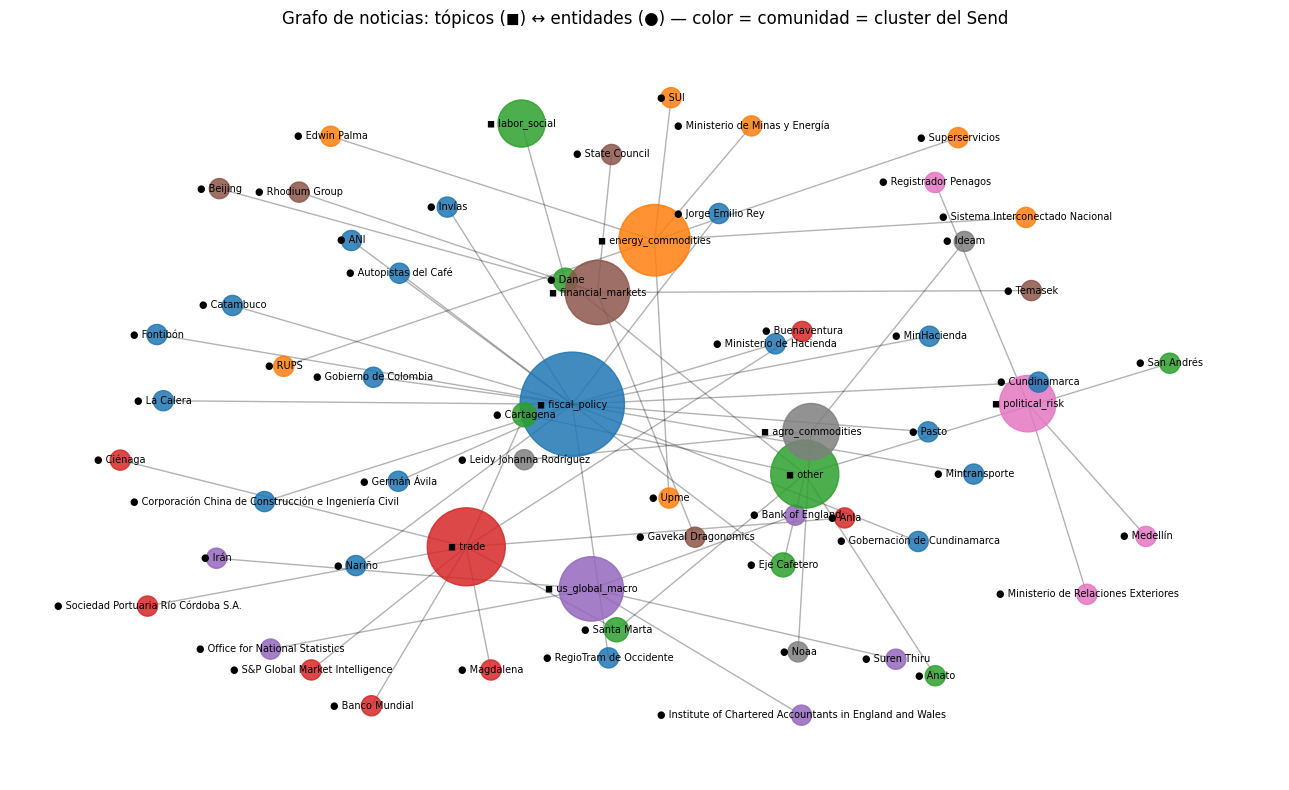

In [7]:
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

G = nx.Graph()
for it in analysis.items:
    t = f"◼ {it.topic}"
    G.add_node(t, kind="topic")
    for e in it.entities:
        en = f"● {e}"
        G.add_node(en, kind="entity")
        w = (G.get_edge_data(t, en) or {}).get("weight", 0)
        G.add_edge(t, en, weight=w + 1)

communities = list(greedy_modularity_communities(G, weight="weight"))
bridges = [n for n in G.nodes if G.nodes[n]["kind"] == "entity"
           and len({nb for nb in G.neighbors(n) if G.nodes[nb]["kind"] == "topic"}) > 1]
print(f"{G.number_of_nodes()} nodos · {G.number_of_edges()} aristas · "
      f"{len(communities)} comunidades · puentes entre tópicos: {bridges or 'ninguno'}")

fig, ax = plt.subplots(figsize=(13, 8))
pos = nx.spring_layout(G, k=0.65, seed=42, weight="weight")
palette = plt.colormaps["tab10"].colors
colors = [palette[next(ci for ci, c in enumerate(communities) if n in c) % 10] for n in G.nodes]
sizes = [900 + 250 * int(G.degree(n)) if G.nodes[n]["kind"] == "topic"
         else 120 + 90 * int(G.degree(n)) for n in G.nodes]
nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, alpha=0.85, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
ax.set_title("Grafo de noticias: tópicos (◼) ↔ entidades (●) — color = comunidad = cluster del Send")
ax.axis("off"); plt.tight_layout(); plt.show()

## 5. El sistema multiagéntico — la respuesta explícita: ¿qué patrón es?

**No es UN patrón: es una composición de cinco, cada uno resolviendo un problema
distinto.** El dominante es **orchestrator-workers + evaluator**; los demás son capas
de soporte. Este era el dilema original del proyecto ("¿prompt chaining, routing,
parallelization u orchestrator-worker?") y esta es la respuesta final:

| Patrón (tu curso) | Nodo(s) en este sistema | Qué problema resuelve |
|---|---|---|
| **Parallelization** (módulo 12 LCEL / ramas del grafo) | `fetch_fx` ‖ `fetch_market` ‖ `fetch_news` desde START; los N workers en un mismo superstep | Las señales son independientes: descargarlas y analizarlas a la vez |
| **Routing** (módulo 16) | `check_materiality` → `add_conditional_edges` → `orchestrate` o `skip_news` | Control de costo: un día sin noticia material no gasta tokens de análisis |
| **Orchestrator-workers** (módulos 13-15, + la API `Send` que el curso NO cubre) | `orchestrate` → `Send("topic_worker", cluster)` × N → reducers `operator.add` | La cantidad de analistas la decide el DATO (los clusters del §4), no el código — un grafo estático no puede |
| **Prompt chaining** (módulo 03) | dentro de cada `topic_worker`: extraer → clasificar → canal de transmisión → impacto | Sub-pasos secuenciales de razonamiento por cluster |
| **Evaluator / racionalidad** (sin módulo equivalente — aporte original) | `adjudicate` (`defer=True`, tier judge) | Reconcilia noticias vs serie vs contexto de mercado; abogado del diablo obligatorio; confianza ACOTADA por validadores Pydantic, no por el prompt |

**Las dos reglas de oro del diseño:**
1. El LLM solo razona sobre TEXTO; todos los NÚMEROS (señales, pesos, confianza,
   evaluación) los produce código determinista. El modelo no puede inventarse un score.
2. Un nodo nuevo solo entra si toma una decisión que un nodo determinista no podía
   tomar — el multiagente se gana con necesidad, no con ambición.

Importing plotly failed. Interactive plots will not work.


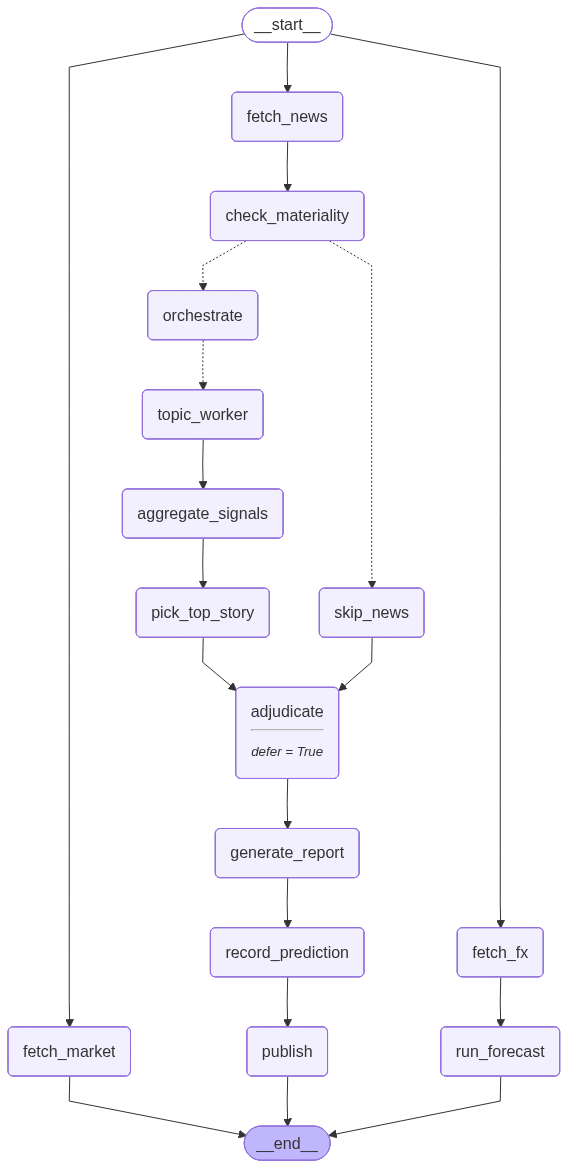

In [8]:
# El grafo LangGraph, RENDERIZADO (no texto): éste es el sistema completo
from IPython.display import Image, display

from cop_fx.agents.graph import build_graph

compiled = build_graph().compile()
try:
    display(Image(compiled.get_graph().draw_mermaid_png()))
except Exception as exc:
    print(f"(render remoto no disponible: {exc} — versión texto)\n")
    print(compiled.get_graph().draw_mermaid())

## 6. La corrida completa → la predicción de la dirección

Todo lo anterior, orquestado en una sola invocación — lo mismo que ejecuta
`uv run cop-fx run` cada día.

In [9]:
from cop_fx.agents.graph import run_pipeline

final_state = run_pipeline()

print("\n=== resumen de la corrida ===")
print(f"TRM            : {final_state.get('latest_rate', 0):,.2f} ({final_state.get('rate_change_pct', 0):+.2f}% 30d)")
print(f"Mercado (ayer) : {final_state.get('market_signal', {})}")
print(f"¿Día material? : {final_state.get('has_material_news')}")
print(f"Clusters (Send): { {t: len(i) for t, i in final_state.get('clusters', {}).items()} }")
print(f"Errores        : {final_state.get('errors', [])}")

16:49:46  INFO      cop_fx.data.fx_fetcher  —  FX source: TRM datos.gov.co


16:49:46  INFO      cop_fx.data.fx_fetcher  —  Fetched 236 FX rows (start=2025-06-12, end=2026-06-12)


16:49:46  INFO      cop_fx.data.cnn_fetcher  —  CNNColombiaFetcher: starting (max=100)


16:49:47  INFO      cop_fx.agents.nodes  —  Market context: down (equity +5.48%, dxy -0.05%, brent -4.06%)


16:49:47  WARNING   cop_fx.data.cnn_fetcher  —  RSS feed returned 0 entries: https://cnnespanol.cnn.com/colombia/feed/


...

16:50:07  INFO      cop_fx.agents.nodes  —  Top story: Ministerio de Hacienda ajustó al alza meta de déficit fiscal y de inflación para el cierre del año (La República - Economía)


16:50:12  INFO      cop_fx.agents.nodes  —  DirectionalCall: down (confianza=0.47, reconciliación=diverge)


16:50:12  INFO      cop_fx.tracking.predictions  —  Prediction saved: 2026-06-12 → down (0.47)


16:50:12  INFO      cop_fx.agents.nodes  —  publish: skipped (publish_enabled=False)



=== resumen de la corrida ===
TRM            : 3,513.54 (-2.22% 30d)
Mercado (ayer) : {'direction': 'down', 'equity_ret_1d_pct': 5.485, 'dxy_ret_1d_pct': -0.053, 'brent_ret_1d_pct': -4.061}
¿Día material? : True
Clusters (Send): {'fiscal_policy': 8, 'energy_commodities': 7, 'political_risk': 7, 'trade': 5, 'environment_climate': 3, 'other': 9}
Errores        : []


In [10]:
call = final_state["directional_call"]
ARROW = {"down": "⬇️ USD/COP BAJA (COP se fortalece)",
         "up": "⬆️ USD/COP SUBE (COP se debilita)",
         "neutral": "⏸️ NEUTRAL — abstención"}

print("=" * 70)
print(f"  {ARROW[call['direction']]}")
print(f"  confianza {call['confidence']:.2f} · horizonte {call['horizon_days']}d · reconciliación: {call['reconciliation']}")
print("=" * 70)
print(f"  noticias : {call['news_signal']['direction']} (score {call['news_signal']['score']})")
print(f"  serie    : {call['ts_signal']['direction']} ({call['ts_signal']['yhat_delta_pct']:+.2f}%)")
print(f"  mercado  : {final_state.get('market_signal', {}).get('direction', 'n/d')} (contexto, no voto)")
print("-" * 70)
print(f"RACIONAL:\n{call['rationale']}\n")
print(f"ABOGADO DEL DIABLO:\n{call['devils_advocate']}")

  ⬇️ USD/COP BAJA (COP se fortalece)
  confianza 0.47 · horizonte 7d · reconciliación: diverge
  noticias : up (score -2.9)
  serie    : down (-0.45%)
  mercado  : down (contexto, no voto)
----------------------------------------------------------------------
RACIONAL:
Los señales divergen: el news signal es alcista para USD/COP (USD/COP UP) por el deterioro fiscal y de inflación anunciado por Hacienda, mientras que el time-series signal apunta a USD/COP DOWN con un yhat_delta_pct de -0.447. Dado el peso del titular top del día —"Ministerio de Hacienda ajustó al alza meta de déficit fiscal y de inflación para el cierre del año"—, considero que la señal de noticias debe dominar en el horizonte de 7 días porque afecta directamente el canal de country risk, necesidades de financiación y la percepción sobre el ancla fiscal. Además, los clusters de riesgo político y el sesgo macro externo siguen inclinándose a mayor presión sobre el COP. El contexto de mercado aporta un contrapeso: la acció

## 7. Medición — el sistema rinde cuentas

Cada corrida deja su predicción en `predictions`; al vencer el horizonte se califica
sola contra la TRM real. Hit-rate, matriz de confusión y accuracy-por-confianza son
las métricas (dirección, no MAPE). El backtest de la serie vive en la notebook 02.

In [11]:
from cop_fx.tracking import PredictionStore

preds = PredictionStore().all()
print(f"{len(preds)} predicciones registradas")
preds[["run_date", "direction", "confidence", "reconciliation",
       "news_direction", "ts_direction", "latest_rate", "actual_direction", "hit"]]

1 predicciones registradas


,run_date,direction,confidence,reconciliation,news_direction,ts_direction,latest_rate,actual_direction,hit
0,2026-06-12,down,0.47,diverge,up,down,3513.54,None,None


In [12]:
# Conclusión GENERADA de esta corrida
ns, ts = call["news_signal"], call["ts_signal"]
mkt = final_state.get("market_signal", {})
print(f"""
┌─ CONCLUSIÓN DE LA CORRIDA ─────────────────────────────────────────
│ {len(final_state.get('raw_articles', []))} titulares → día {'MATERIAL' if final_state.get('has_material_news') else 'no material'} → {len(final_state.get('clusters', {}))} analistas (Send) → {len(final_state.get('analyzed_articles', []))} artículos GOLD
│
│ noticias: {ns['direction']:>7} (score {ns['score']:+.2f})   serie: {ts['direction']:>7} ({ts['yhat_delta_pct']:+.2f}%)
│ mercado : {mkt.get('direction', 'n/d'):>7} (equity ayer {mkt.get('equity_ret_1d_pct', 0):+.2f}%)
│
│ VEREDICTO: USD/COP {call['direction'].upper()} a {call['horizon_days']} días · confianza {call['confidence']:.2f} · {call['reconciliation']}
│ Registrado en data/predictions.db — se autocalifica al vencer el horizonte.
└────────────────────────────────────────────────────────────────────
""")


┌─ CONCLUSIÓN DE LA CORRIDA ─────────────────────────────────────────
│ 100 titulares → día MATERIAL → 6 analistas (Send) → 39 artículos GOLD
│
│ noticias:      up (score -2.90)   serie:    down (-0.45%)
│ mercado :    down (equity ayer +5.49%)
│
│ VEREDICTO: USD/COP DOWN a 7 días · confianza 0.47 · diverge
│ Registrado en data/predictions.db — se autocalifica al vencer el horizonte.
└────────────────────────────────────────────────────────────────────



---
## Cierre

Acabas de ver el sistema completo: **scraping → monedas → golden query (topics) →
grafo de noticias → sistema multiagéntico (routing + Send + chaining + evaluator) →
predicción de la dirección → medición**. Los otros dos cuadernos profundizan las
patas: `01_noticias` (la ingesta y la taxonomía) y `02_series_de_tiempo` (el
diagnóstico cuantitativo y qué activos se ganaron su lugar).

**Para dominar LangGraph replicando esto**: reconstruye el grafo en una notebook
vacía en este orden — (1) un nodo con `with_structured_output`, (2) el router con
`add_conditional_edges`, (3) el fan-out con `Send` + reducers, (4) el join con
`defer=True` y un solo trigger. Verifícate contra `tests/unit/test_graph_nodes.py`.